In [21]:
import jsonlines as jsonl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
with jsonl.open('dota2_metrics.jsonl') as f:
# with jsonl.open('cod_metrics.jsonl') as f:
    metrics = [e for e in f]

In [23]:
metrics_df = pd.DataFrame([{(outerKey, innerKey): values for outerKey, innerDict in dictionary.items() for innerKey, values in innerDict.items()} for dictionary in metrics])

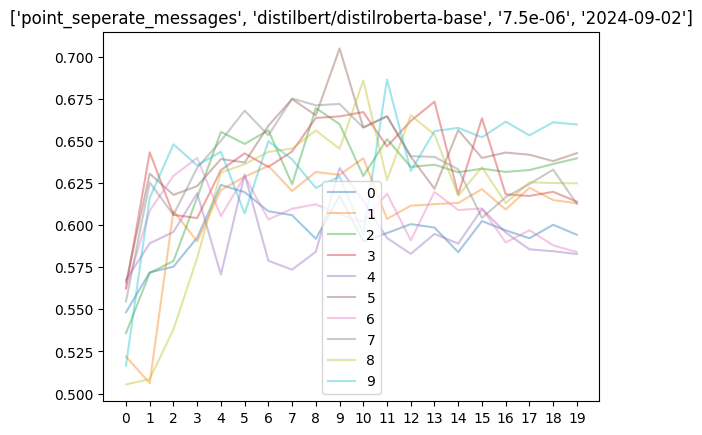

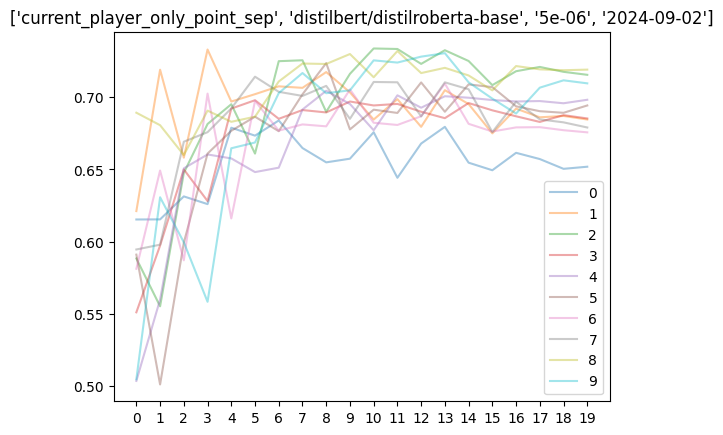

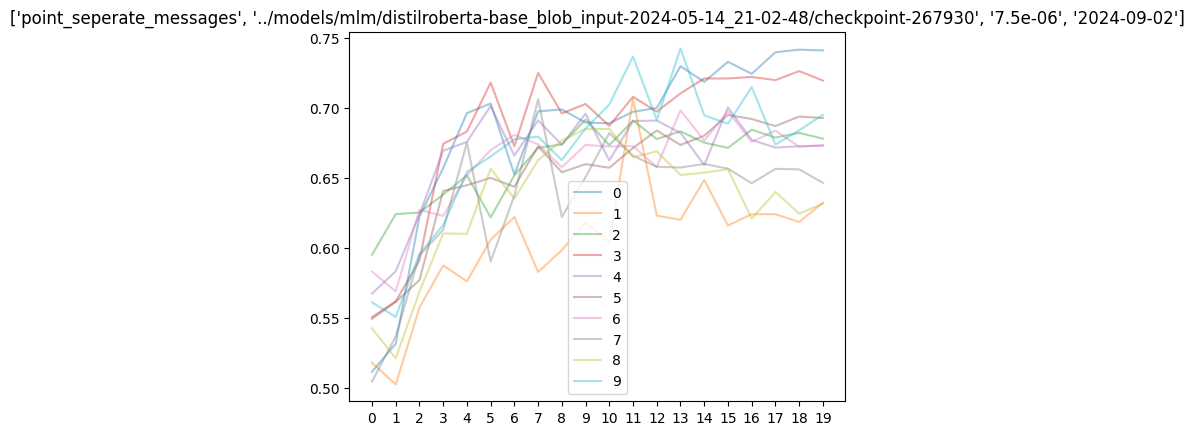

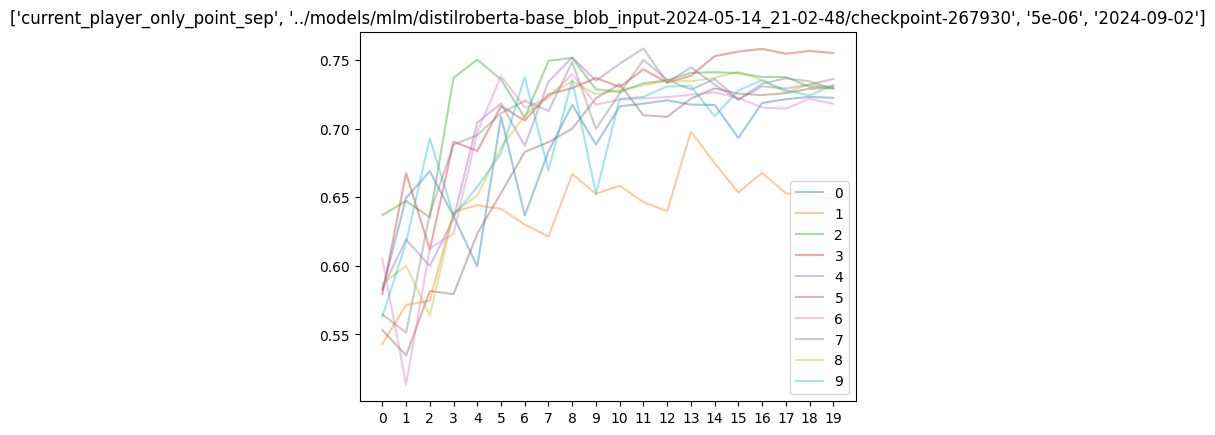

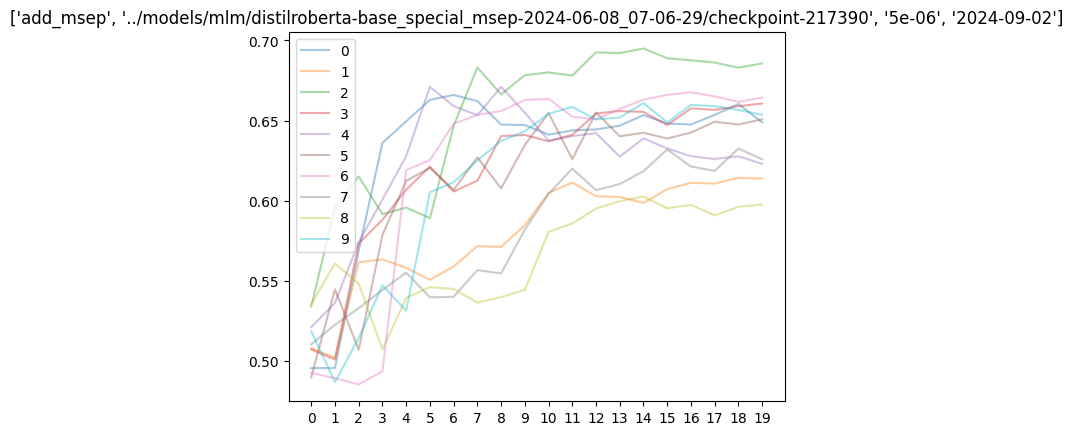

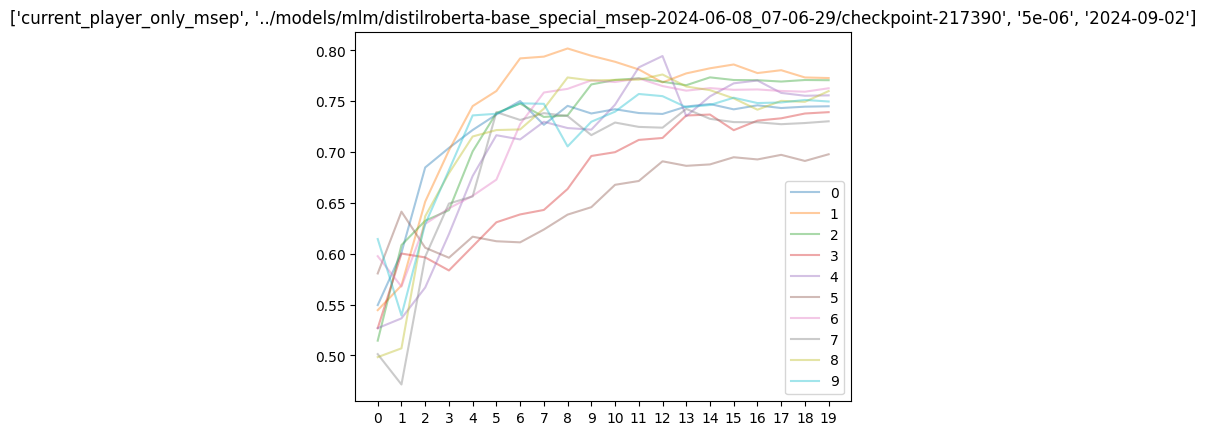

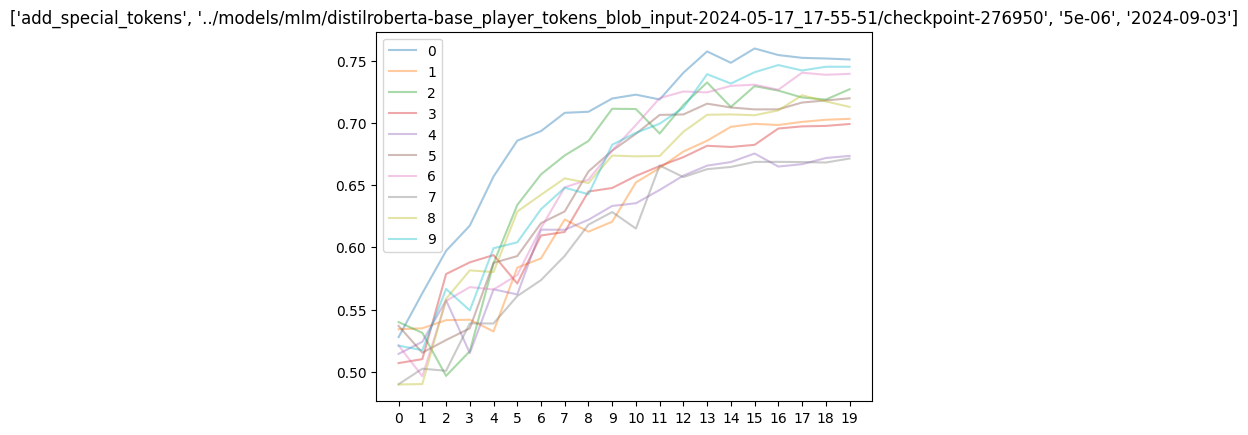

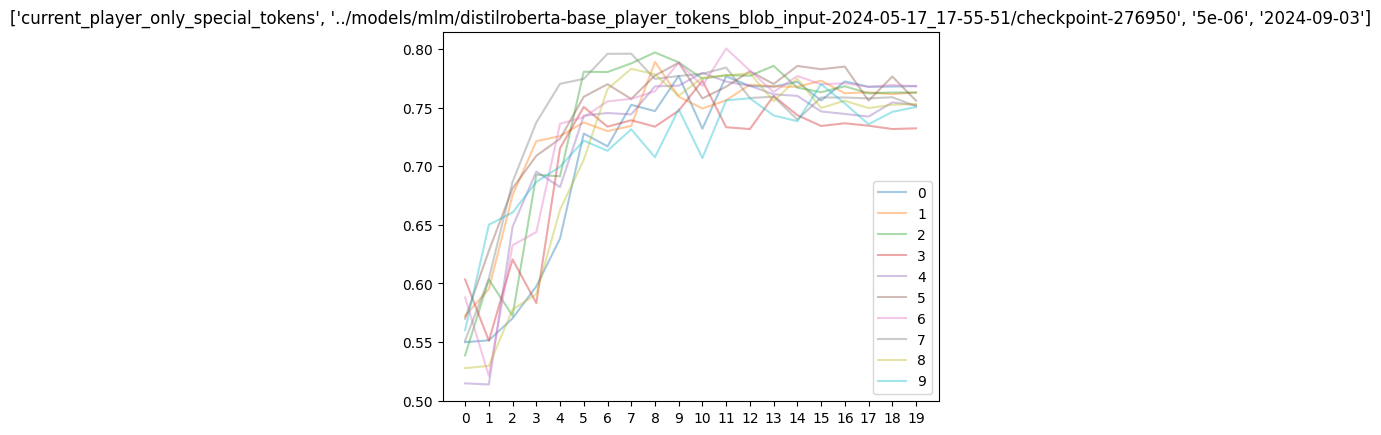

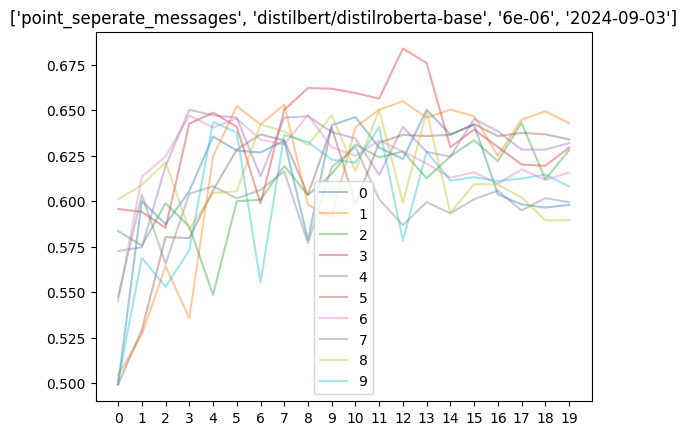

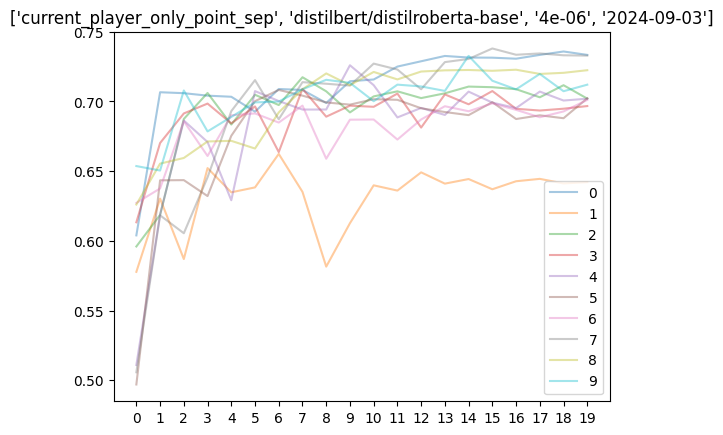

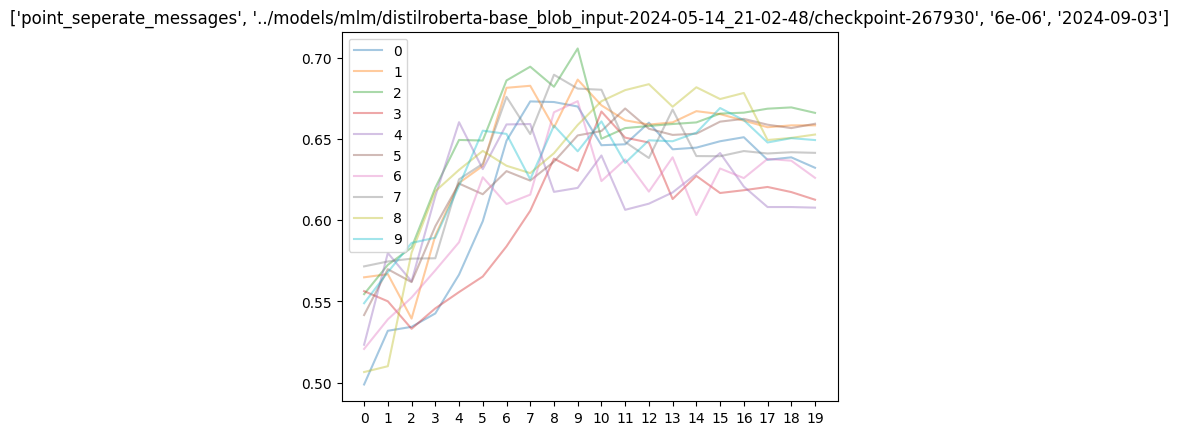

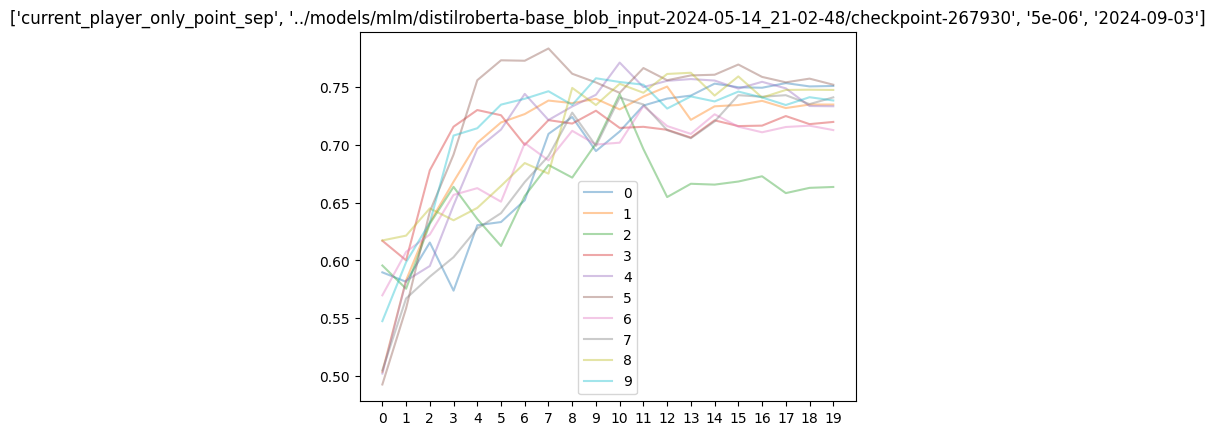

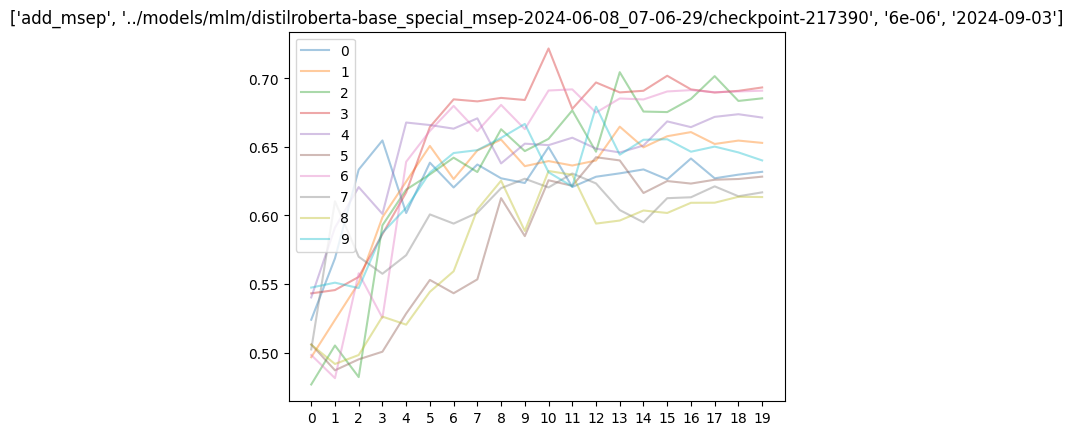

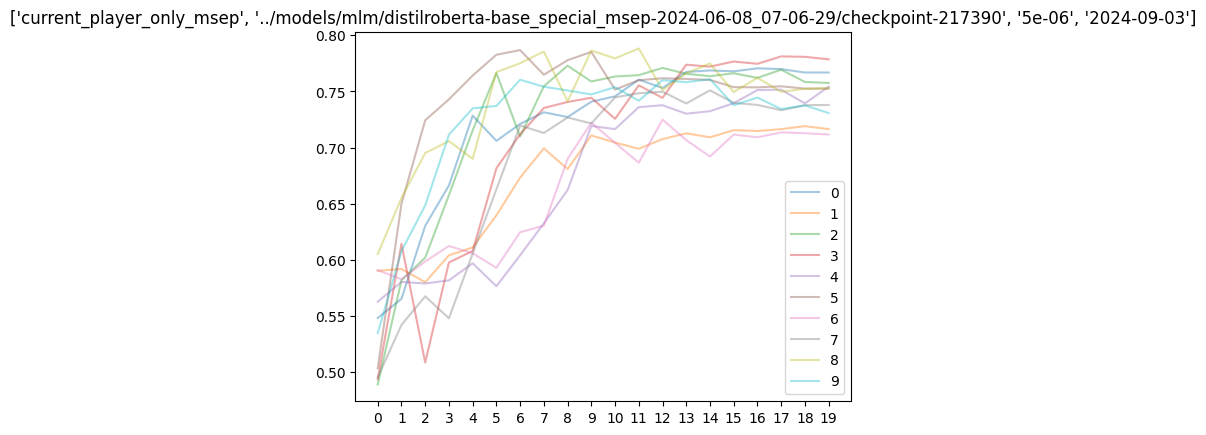

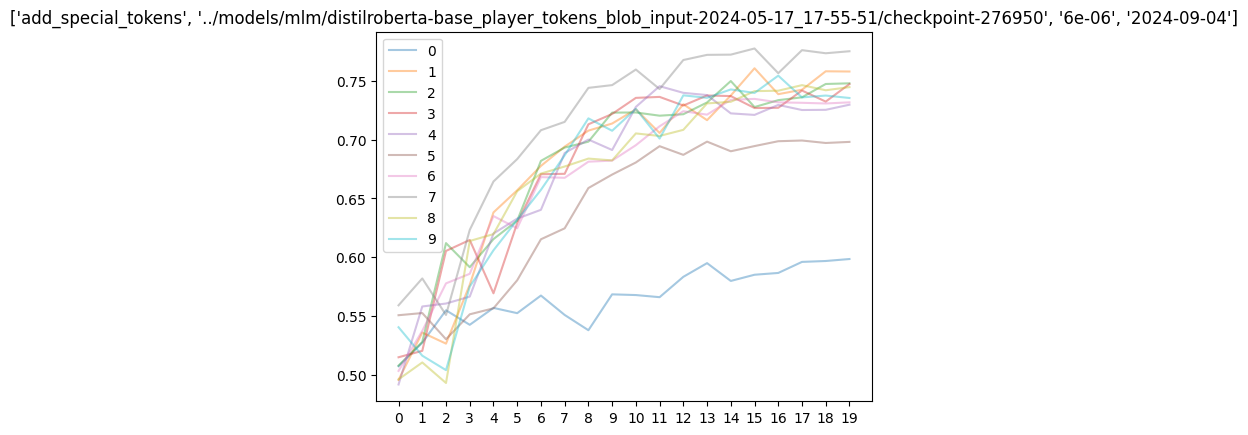

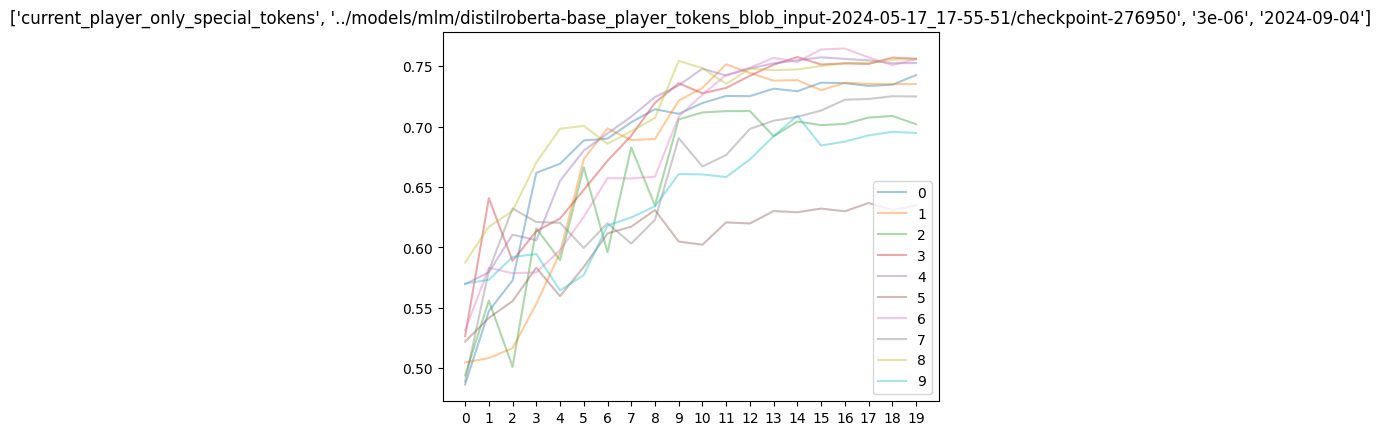

In [24]:
to_plot = [('metrics', 'bal_acc')]#, ('metrics', 'train_loss')]#, ('metrics', 'test_loss')]
to_group = [('metadata', 'message_concatenator'), ('metadata', 'base_model'), ('metadata', 'lr'), ('metadata', 'experiment_start')]
to_agg = []#[('metrics', 'epoch')]
metric_cols = [ (t, m) for t in ['metrics'] for m in ['bal_acc', 'auc', 'prec', 'rec'] ]

for group, subdf in metrics_df.groupby(to_group, sort=False):
    plt.figure()

    if to_agg:
        std_mean_df = subdf[to_agg+metric_cols].groupby(to_agg).aggregate(['mean', 'std'])
        for col in to_plot:
            best_epoch = std_mean_df[(*col, 'mean')].idxmax()
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')], label='mean '+str(col))
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')]+std_mean_df[(*col, 'std')], label='std '+str(col), color='grey')
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')]-std_mean_df[(*col, 'std')], color='grey')

            plt.axvline(best_epoch, color='black', linestyle='--', label='best epoch '+str(col))
            plt.xticks(std_mean_df.index)
        print(group)
        print(std_mean_df.loc[best_epoch])
    else:
        for col in to_plot:
            for n, run in subdf.groupby([('metadata', 'run')]):
                dat = run[col].tolist()
                plt.plot(dat, label=str(n[0]), alpha=.4)
            plt.xticks(range(len(dat)))

    plt.title(str([str(g).split()[0] for g in group]))
    plt.legend()